In [430]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [431]:
file = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_mu_cc_1000_events_new.root")
file2 = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_mu_cc_1000_events_.root")
file3 = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_tau_cc_1000_events_new.root")
file4 = uproot.open("/lstr/sahara/dune/arahe/CP2Course/CP2GroupProject/TylerStuff/CCode/Analysis/gen1_tau_cc_1000_events_.root")

In [432]:
tree = file["ana;1"]

In [433]:
branch = tree["gen1;1"]

In [434]:
Reco = branch.arrays(['eventID',
                      'recoNParticles',
                      'reco',
                      'recoGeneration',
                      'recoTrackLength',
                      'recoTrackScore',
                      'recodEdx',
                      'recoResidualRange'])
Sim = branch.arrays(['simNParticles',
                     'sim',
                     'simGeneration',
                     'simPdgCode',
                     'simEnergy',
                     'simID'])

In [435]:
rec = ak.zip({
    "eventID" : Reco['eventID'],
    "recoNParticles" : Reco['recoNParticles'],
    "recoGeneration" : Reco['recoGeneration'],
    "recoTrackLength" : Reco['recoTrackLength'],
    "recoTrackScore" : Reco['recoTrackScore'],
    "recodEdx" : Reco['recodEdx'],
    "recoResidualRange" : Reco['recoResidualRange']
})

In [436]:
sim = ak.zip({
    "simNParticles" : Sim['simNParticles'],
    "sim" : Sim["sim"],
    "simGeneration" : Sim['simGeneration'],
    "simPdgCode" : Sim["simPdgCode"],
    "simEnergy" : Sim['simEnergy'],
    "simID" : Sim["simID"]
})

In [477]:
#ak.mean(rec.recoNParticles)
#max(rec.recoResidualRange)
ak.sum(rec[0].recodEdx[0])

73.15138

In [476]:
dedex = rec.recodEdx
ak.sum(dedex, axis=-1)

<Array [[73.2, 4.07e+03], ..., [2.45e+03, ...]] type='935 * var * float32'>

In [438]:
print(ak.sum(rec.eventID==4))

1344


In [440]:
#plt.scatter(ak.ravel(rec.recodEdx), ak.ravel(rec.recoResidualRange))
#plt.xlim(0, 10)
#plt.ylim(0,100)
#plt.show()

In [73]:
def energyperlength(energy, length):
    #Calculates Total Energy using dEdx and Tracklength
    result = energy * length
    return result

In [74]:
#energyperlength(rec.recodEdx,rec.recoTrackLength)

In [485]:
def recocuts(reco):
    #Apply cuts
    e_and_l_cut = (reco.recoTrackScore>0.8) & (ak.sum(dedex, axis=-1)<1000)#& (reco.recoResidualRange<15) #& (reco.recodEdx>1.9) & (reco.recodEdx<2.1) & (reco.recoResidualRange>10) &(reco.recoNParticles<3)
    cleaned_e_and_l = reco[e_and_l_cut]
    #Get Total Energy
    #e_per_l = energyperlength(cleaned_e_and_l.recodEdx, cleaned_e_and_l.recoResidualRange)
    return cleaned_e_and_l #e_per_l

In [486]:
thething = recocuts(rec)
thething

<Array [[[], []], [[], ..., []], ..., [[], []]] type='935 * var * var * {ev...'>

In [487]:
flatten_data_for_histogram = ak.ravel(ak.Array(thething))
flatten_data_for_histogram

<Array [8, 8, 8, 8, 8, 8, ..., 157, 157, 158, 159, 160] type='404033 * float64'>

In [488]:
print(len(flatten_data_for_histogram))

404033


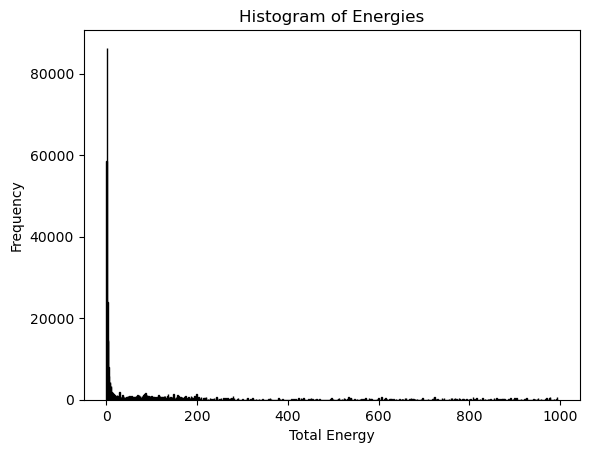

In [490]:
plt.hist(flatten_data_for_histogram, bins=1000, color = "blue", edgecolor = 'black')
#plt.xlim(0, 2e4)
#plt.ylim(0,5)
plt.xlabel('Total Energy')
plt.ylabel('Frequency')
plt.title('Histogram of Energies')
plt.show()

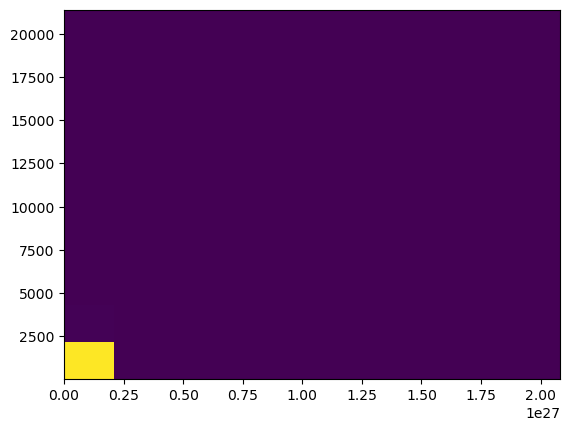

In [426]:
this = np.asarray(ak.ravel(rec.recodEdx))
that = np.asarray(ak.ravel(rec.recoResidualRange))
plt.hist2d(this, that)
#plt.xlim(0, 1e15)
#plt.ylim(0,4000)
plt.show()
#that

In [392]:
def simcuts(sim):
    #Apply cuts
    e_cut = (sim.simPdgCode == 13)
    cleaned_e = sim[e_cut]
    return cleaned_e.simEnergy

In [264]:
yessir = simcuts(sim)
yessir

<Array [[2.29], [0.696], ..., [0.362], [0.98]] type='935 * var * float32'>

In [265]:
flatten_simdata_for_histogram = ak.ravel(ak.Array(yessir))
flatten_simdata_for_histogram

<Array [2.29, 0.696, 1.45, 5.79, ..., 9.09, 0.362, 0.98] type='1019 * float32'>

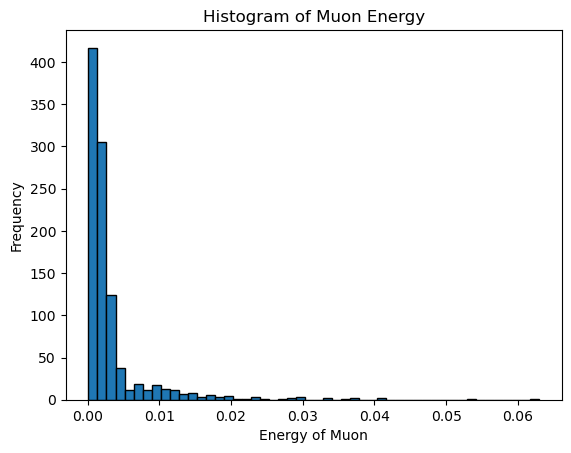

In [293]:
plt.hist(flatten_simdata_for_histogram, bins=50, edgecolor = 'black')
#plt.xlim(0, 0.5)
#plt.ylim(0,5)
plt.xlabel('Energy of Muon')
plt.ylabel('Frequency')
plt.title('Histogram of Muon Energy')
plt.show()

In [267]:
print(min(flatten_simdata_for_histogram), max(flatten_simdata_for_histogram))

0.12550557 62.993683


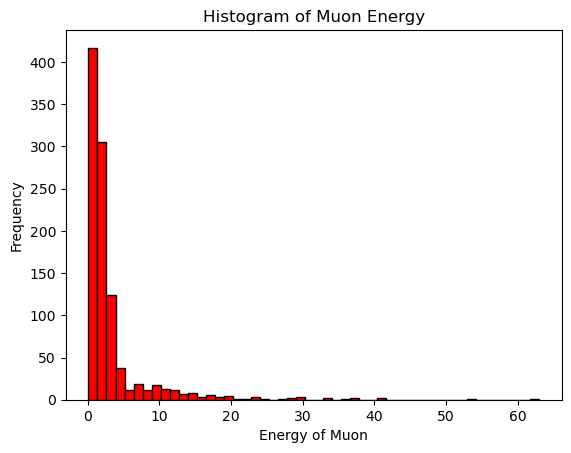

In [268]:
#plt.hist(flatten_data_for_histogram, bins=50, color = "blue", edgecolor = 'black')
plt.hist(flatten_simdata_for_histogram, bins=50, color = "red", edgecolor = 'black')
#plt.xlim(0, 60)
#plt.ylim(0,8)
plt.xlabel('Energy of Muon')
plt.ylabel('Frequency')
plt.title('Histogram of Muon Energy')
plt.show()